In [39]:
import os
os.chdir(r'C:\Users\66959\Desktop\stats\data')
os.getcwd()

'C:\\Users\\66959\\Desktop\\stats\\data'

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [41]:
orig_df1 = pd.read_csv('worldbank_2017_2021.csv')
orig_df2 = pd.read_excel('countries_regions.xlsx')

In [42]:
orig_df = pd.merge(orig_df1, orig_df2, left_on='Country Name', right_on='CountryName')

In [43]:
orig_df.head()

,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",CountryName,Region,ThirdWorld
0,Afghanistan,2017,5.99,58.12,26.42,11.80,2091.4,99.21,20.45,99.84,...,62.58,12.20,NaN,NaN,NaN,NaN,NaN,Afghanistan,South Asia,Yes
1,Albania,2017,14.56,42.86,19.02,22.34,4813.0,105.84,99.81,103.88,...,29.97,17.04,NaN,NaN,NaN,NaN,NaN,Albania,Eastern Europe,No
2,Algeria,2017,3.16,17.36,11.03,3.14,990.3,104.40,20.84,102.87,...,2.33,1.70,NaN,NaN,NaN,NaN,NaN,Algeria,Africa,No
3,American Samoa,2017,NaN,13.90,NaN,4.65,NaN,NaN,41.67,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,American Samoa,Australia and Oceanea,No
4,Andorra,2017,NaN,40.04,0.56,1.74,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Andorra,Western Europe,No


In [44]:
orig_df = orig_df.drop(columns=['CountryName'])

In [45]:
df = orig_df.copy()

# Train-test split

In [46]:
X = df.drop(columns=["GNI per capita, PPP (current international $)"])
y = df["GNI per capita, PPP (current international $)"]

In [47]:
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

In [49]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((772, 196), (194, 196), (772,), (194,))

# Data preprocessing 

## Handling missing values

In [50]:
print((X_train.isna().mean() * 100).to_string())

Country Name                                                                                                                                     0.000000
Year                                                                                                                                             0.000000
Agricultural irrigated land (% of total agricultural land)                                                                                      74.352332
Agricultural land (% of land area)                                                                                                               2.072539
Agriculture, forestry, and fishing, value added (% of GDP)                                                                                       4.663212
Arable land (% of land area)                                                                                                                     3.367876
Cereal yield (kg per hectare)                                               

In [51]:
print((y_train.isna().mean() * 100))

0.0


In [52]:
threshold = 0.40
missing_ratio = X_train.isna().mean()
drop_cols = missing_ratio[missing_ratio > threshold].index

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [53]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object','category']).columns

In [54]:
cat_cols

Index(['Country Name', 'Region', 'ThirdWorld'], dtype='object')

In [55]:
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())

X_train[cat_cols] = X_train[cat_cols].fillna(X_train[cat_cols].mode())
X_test[cat_cols] = X_test[cat_cols].fillna(X_train[cat_cols].mode())

In [56]:
print((X_train.isna().mean() * 100).to_string())

Country Name                                                                                       0.0
Year                                                                                               0.0
Agricultural land (% of land area)                                                                 0.0
Agriculture, forestry, and fishing, value added (% of GDP)                                         0.0
Arable land (% of land area)                                                                       0.0
Cereal yield (kg per hectare)                                                                      0.0
Crop production index (2014-2016 = 100)                                                            0.0
Fertilizer consumption (kilograms per hectare of arable land)                                      0.0
Food production index (2014-2016 = 100)                                                            0.0
Forest area (% of land area)                                             

## Handling Outliers

In [57]:
def remove_outliers_sync(X, y, outlier_vars):
    combined = pd.concat([X, y], axis=1)
    target_col = y.name
    
    for _var in outlier_vars:
        if pd.api.types.is_numeric_dtype(combined[_var]) and combined[_var].dtype != 'bool':
            q1 = combined[_var].quantile(0.25)
            q3 = combined[_var].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            combined = combined[(combined[_var] >= lower_bound) & (combined[_var] <= upper_bound)]
            
    return combined.drop(columns=[target_col]), combined[target_col]

## Encoding

In [58]:
cat_cols

Index(['Country Name', 'Region', 'ThirdWorld'], dtype='object')

In [59]:
X_train.shape

(772, 107)

In [60]:
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=True)
    return df

In [61]:
X_train = onehot_encoder_selected(X_train, cat_cols)
X_test = onehot_encoder_selected(X_test, cat_cols)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [62]:
X_train.shape

(772, 310)

In [63]:
X_test.shape

(194, 310)

## Scaling

In [64]:
from sklearn.preprocessing import StandardScaler

def scale_standard(X_train, X_test):
    scaler = StandardScaler()
    
    train_arr = scaler.fit_transform(X_train)
    test_arr = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(train_arr, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(test_arr, columns=X_test.columns, index=X_test.index)
    
    return X_train_scaled, X_test_scaled

# Feature selection

In [65]:
X_train.head()

,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
249,2018,6.46,1.70,4.32,3914.7,107.06,111.81,108.98,38.70,3470020.70,...,False,True,False,False,False,False,False,False,False,False
666,2020,43.79,5.91,19.82,6050.7,129.61,82.46,115.06,42.73,21879.10,...,False,False,False,False,False,False,False,False,False,False
868,2021,57.84,5.73,25.28,3297.4,142.51,105.59,126.99,13.83,11432.97,...,False,False,False,False,False,False,False,True,False,False
982,2021,49.96,3.79,10.33,3878.9,111.91,109.25,114.11,33.73,655643.17,...,False,True,False,False,False,False,False,False,False,False
1044,2021,75.77,27.82,25.38,820.4,100.49,3.86,100.59,2.84,5220.80,...,True,False,False,False,False,False,False,False,False,False


## Low Variance Filtering

In [66]:
X_train.var().sort_values(ascending=False)

GNI, PPP (current international $)                               4.496478e+24
GDP (current US$)                                                1.733799e+24
Total reserves (includes gold, current US$)                      8.853657e+22
Merchandise exports (current US$)                                6.900418e+22
Merchandise imports (current US$)                                5.247385e+22
                                                                     ...     
Country Name_Belarus                                             2.587313e-03
Country Name_Netherlands                                         2.587313e-03
School enrollment, primary (gross), gender parity index (GPI)    1.618983e-03
Country Name_India                                               1.295337e-03
Country Name_Cameroon                                            1.295337e-03
Length: 310, dtype: float64

In [67]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
selector.fit(X_train)

updated_vars = X_train.columns[selector.get_support()].tolist()
updated_vars

['Year',
 'Agricultural land (% of land area)',
 'Agriculture, forestry, and fishing, value added (% of GDP)',
 'Arable land (% of land area)',
 'Cereal yield (kg per hectare)',
 'Crop production index (2014-2016 = 100)',
 'Fertilizer consumption (kilograms per hectare of arable land)',
 'Food production index (2014-2016 = 100)',
 'Forest area (% of land area)',
 'Forest area (sq. km)',
 'Land area (sq. km)',
 'Livestock production index (2014-2016 = 100)',
 'Permanent cropland (% of land area)',
 'Rural population',
 'Rural population (% of total population)',
 'Surface area (sq. km)',
 'Access to electricity (% of population)',
 'Annual freshwater withdrawals, total (% of internal resources)',
 'Mortality rate, under-5 (per 1,000 live births)',
 'Population growth (annual %)',
 'Population, total',
 'Primary completion rate, total (% of relevant age group)',
 'Renewable energy consumption (% of total final energy consumption)',
 'Urban population',
 'Urban population (% of total popu

In [68]:
len(updated_vars)

310

In [69]:
X_train = X_train[updated_vars]
X_test = X_test[updated_vars]
X_train.head()

,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
249,2018,6.46,1.70,4.32,3914.7,107.06,111.81,108.98,38.70,3470020.70,...,False,True,False,False,False,False,False,False,False,False
666,2020,43.79,5.91,19.82,6050.7,129.61,82.46,115.06,42.73,21879.10,...,False,False,False,False,False,False,False,False,False,False
868,2021,57.84,5.73,25.28,3297.4,142.51,105.59,126.99,13.83,11432.97,...,False,False,False,False,False,False,False,True,False,False
982,2021,49.96,3.79,10.33,3878.9,111.91,109.25,114.11,33.73,655643.17,...,False,True,False,False,False,False,False,False,False,False
1044,2021,75.77,27.82,25.38,820.4,100.49,3.86,100.59,2.84,5220.80,...,True,False,False,False,False,False,False,False,False,False


## High Correlation Filtering

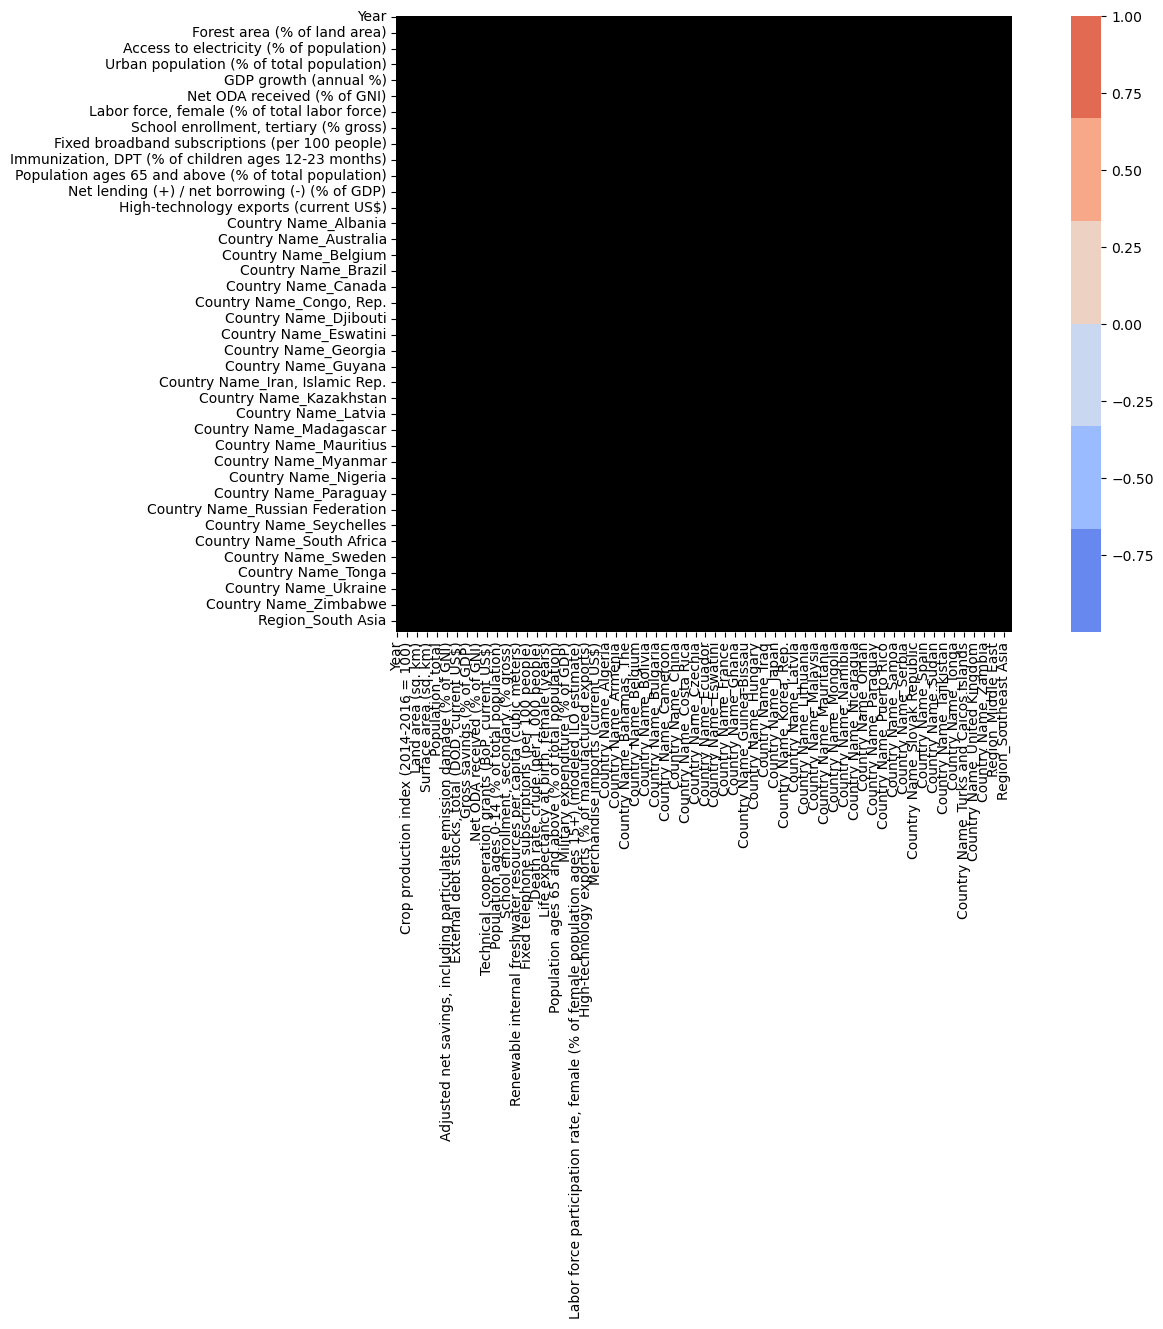

In [70]:
plt.figure(figsize=(15,8))
sns.heatmap(X_train.corr(),
            square=True,
            linewidths=0.25,    
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=False)
plt.show()

In [71]:
import numpy as np

def drop_high_corr_cols_with_target(X, y, threshold=0.8):
    corr = X.corr().abs()
    target_corr = X.apply(lambda col: col.corr(y)).abs()

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    drop_cols = set()

    for col in upper.columns:
        high_corr = upper[col][upper[col] > threshold].index
        for other in high_corr:
            if target_corr[col] < target_corr[other]:
                drop_cols.add(col)
            else:
                drop_cols.add(other)

    return list(drop_cols)

In [72]:
drop_cols = drop_high_corr_cols_with_target(X_train, y_train, threshold=0.8)

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [73]:
X_train.shape

(772, 275)

In [74]:
X_test.shape

(194, 275)

# Modeling 

In [75]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def compute_regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

def compute_mape(y_true, y_pred):
    # Mean Absolute Percentage Error
    # Note: MAPE fails if y_true contains zeros.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def compute_smape(y_true, y_pred):
    # Symmetric Mean Absolute Percentage Error
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def compute_rmsle(y_true, y_pred, neg_mask=0):
    # Root Mean Squared Log Error
    # RMSLE is good for right-skewed data
    # Note: log1p(x) = log(1+x), and the log parameter must be positive. 
    # Therefore, x >= -1. Otherwise, log1p(1+x) encounters an invalid value.
        
    if neg_mask == 1:
        mask = (y_true >= 0) & (y_pred >= 0)
        y_true = y_true[mask]
        y_pred = y_pred[mask]
    
    np_y_true, np_y_pred = np.array(y_true), np.array(y_pred)
    rmsle = np.sqrt(np.mean((np.log1p(np_y_true) - np.log1p(np_y_pred))**2))  # Root Mean Squared Log Error

    return rmsle

In [76]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import pandas as pd
import matplotlib.pyplot as plt

rf_base = RandomForestRegressor(
    n_estimators=100,
    random_state=0
)

rf_base.fit(X_train, y_train)

importances = pd.Series(
    rf_base.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

for n_features in range(5, 100, 5):
    selected_features = importances.head(n_features).index

    X_tr = X_train[selected_features]
    X_te = X_test[selected_features]

    rf = RandomForestRegressor(
        n_estimators=100,
        random_state=0
    )

    rf.fit(X_tr, y_train)
    y_pred = rf.predict(X_te)

    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    print(f"Features: {n_features} | R2: {r2:.4f} | MAPE: {mape:.4f}")

Features: 5 | R2: 0.9520 | MAPE: 0.1973
Features: 10 | R2: 0.9651 | MAPE: 0.1317
Features: 15 | R2: 0.9668 | MAPE: 0.1137
Features: 20 | R2: 0.9696 | MAPE: 0.1147
Features: 25 | R2: 0.9690 | MAPE: 0.1207
Features: 30 | R2: 0.9683 | MAPE: 0.1176
Features: 35 | R2: 0.9639 | MAPE: 0.1166
Features: 40 | R2: 0.9679 | MAPE: 0.1140
Features: 45 | R2: 0.9673 | MAPE: 0.1145
Features: 50 | R2: 0.9666 | MAPE: 0.1109
Features: 55 | R2: 0.9644 | MAPE: 0.1175
Features: 60 | R2: 0.9693 | MAPE: 0.1134
Features: 65 | R2: 0.9662 | MAPE: 0.1147
Features: 70 | R2: 0.9661 | MAPE: 0.1198
Features: 75 | R2: 0.9677 | MAPE: 0.1168
Features: 80 | R2: 0.9662 | MAPE: 0.1171
Features: 85 | R2: 0.9681 | MAPE: 0.1188
Features: 90 | R2: 0.9692 | MAPE: 0.1191
Features: 95 | R2: 0.9667 | MAPE: 0.1162


In [77]:
n_features = 15

features = importances.head(n_features).index
X_train = X_train[features]
X_test  = X_test[features]

In [78]:
from sklearn.linear_model import LinearRegression

model = RandomForestRegressor(
    n_estimators=100,
    random_state=0
)
model.fit(X_train, y_train)

# Use model for predicted responses
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# Measure performances
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  4193.56231902009
MAE:  2100.171134020619
MAPE:  11.366308043478595
R2:  0.9667741305990923
RMSLE:  0.15420281178631673


# Performance evaluation

In [79]:
rmse, mae, r2 = compute_regression_metrics(y_test, y_pred)
mape = compute_mape(y_test, y_pred)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MAPE: ", mape)
print("R2: ", r2)
rmsle = compute_rmsle(y_test, y_pred)
print("RMSLE: ", rmsle)

RMSE:  4193.56231902009
MAE:  2100.171134020619
MAPE:  11.366308043478595
R2:  0.9667741305990923
RMSLE:  0.15420281178631673


In [80]:
y_train_pred = rf.predict(X_tr)
y_test_pred = rf.predict(X_te)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Train R2: {r2_train:.4f}")
print(f"Test R2: {r2_test:.4f}")
print(f"Gap: {r2_train - r2_test:.4f}")

Train R2: 0.9939
Test R2: 0.9667
Gap: 0.0272


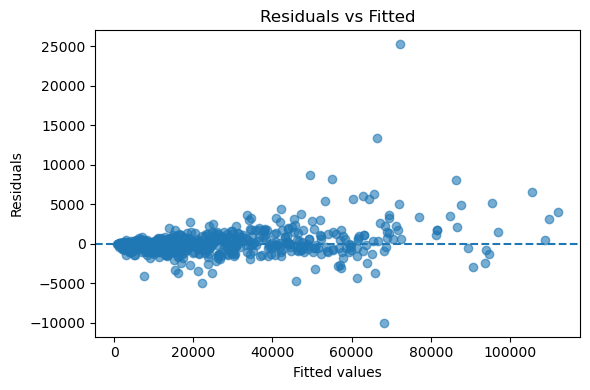

In [81]:
residuals = y_train - y_train_pred

plt.figure(figsize=(6,4))
plt.scatter(y_train_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

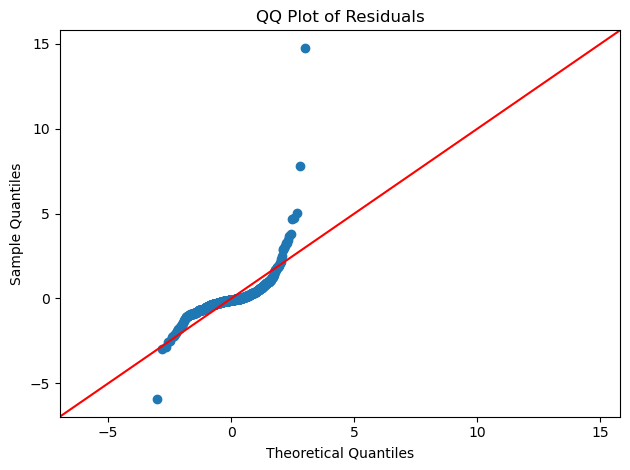

In [82]:
residuals = y_train - y_train_pred

# QQ plot
plt.figure(figsize=(6,4))
sm.qqplot(residuals, line='45', fit=True)
plt.title('QQ Plot of Residuals')
plt.tight_layout()
plt.show()

# Result interpretation

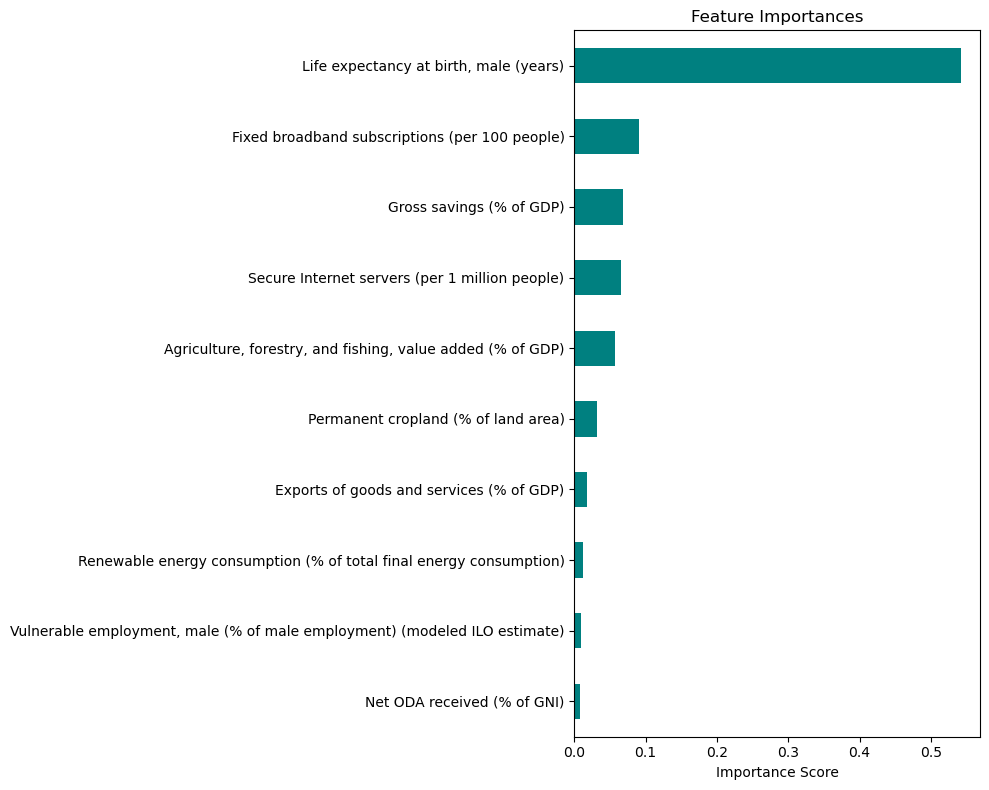

In [83]:
importances = pd.Series(
    rf.feature_importances_, 
    index=rf.feature_names_in_
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.tail(10).plot(kind='barh', color='teal')
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()